In [37]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [38]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, recall_score, precision_score
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.linear_model import Lasso, Ridge
import matplotlib.pyplot as plt
from sklearn.model_selection import LearningCurveDisplay
from sklearn.model_selection import cross_val_score
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import LearningCurveDisplay
from sklearn.metrics import log_loss
from sklearn.metrics import ConfusionMatrixDisplay

In [39]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
breast_cancer = fetch_ucirepo(id=17)

# metadata
print(breast_cancer.metadata)

# variable information
print(breast_cancer.variables)


{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

In [40]:
df = pd.DataFrame(breast_cancer.data.features)
df['diagnosis'] = pd.DataFrame(breast_cancer.data.targets)

# Basic statistic

In [41]:
rename_dict = {
    # Mean features (variablename1 -> variablename_mean)
    'radius1': 'radius_mean',
    'texture1': 'texture_mean',
    'perimeter1': 'perimeter_mean',
    'area1': 'area_mean',
    'smoothness1': 'smoothness_mean',
    'compactness1': 'compactness_mean',
    'concavity1': 'concavity_mean',
    'concave_points1': 'concave_points_mean',
    'symmetry1': 'symmetry_mean',
    'fractal_dimension1': 'fractal_dimension_mean',

    # Standard Error features (variablename2 -> variablename_se)
    'radius2': 'radius_se',
    'texture2': 'texture_se',
    'perimeter2': 'perimeter_se',
    'area2': 'area_se',
    'smoothness2': 'smoothness_se',
    'compactness2': 'compactness_se',
    'concavity2': 'concavity_se',
    'concave_points2': 'concave_points_se',
    'symmetry2': 'symmetry_se',
    'fractal_dimension2': 'fractal_dimension_se',

    # Worst features (variablename3 -> variablename_worst)
    'radius3': 'radius_worst',
    'texture3': 'texture_worst',
    'perimeter3': 'perimeter_worst',
    'area3': 'area_worst',
    'smoothness3': 'smoothness_worst',
    'compactness3': 'compactness_worst',
    'concavity3': 'concavity_worst',
    'concave_points3': 'concave_points_worst',
    'symmetry3': 'symmetry_worst',
    'fractal_dimension3': 'fractal_dimension_worst',
}

# Apply renaming
df = df.rename(columns=rename_dict)

In [42]:
df.shape

(569, 31)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   radius_mean              569 non-null    float64
 1   texture_mean             569 non-null    float64
 2   perimeter_mean           569 non-null    float64
 3   area_mean                569 non-null    float64
 4   smoothness_mean          569 non-null    float64
 5   compactness_mean         569 non-null    float64
 6   concavity_mean           569 non-null    float64
 7   concave_points_mean      569 non-null    float64
 8   symmetry_mean            569 non-null    float64
 9   fractal_dimension_mean   569 non-null    float64
 10  radius_se                569 non-null    float64
 11  texture_se               569 non-null    float64
 12  perimeter_se             569 non-null    float64
 13  area_se                  569 non-null    float64
 14  smoothness_se            5

In [44]:
df['diagnosis'] = np.where(df['diagnosis'] == 'M', 1, 0)

In [45]:
y = df['diagnosis']
X = df.drop(['diagnosis'], axis=1)

In [46]:
X.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [47]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: diagnosis, dtype: int64

In [48]:
df.isnull().sum()

radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave_points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave_points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave_points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
diagnosis                  0
dtype: int64

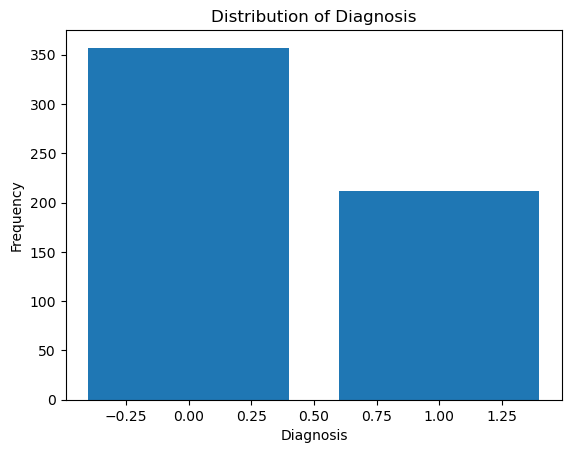

In [49]:
counts = y.value_counts()
plt.bar(counts.index, counts.values)
plt.title('Distribution of Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Frequency')
plt.show()

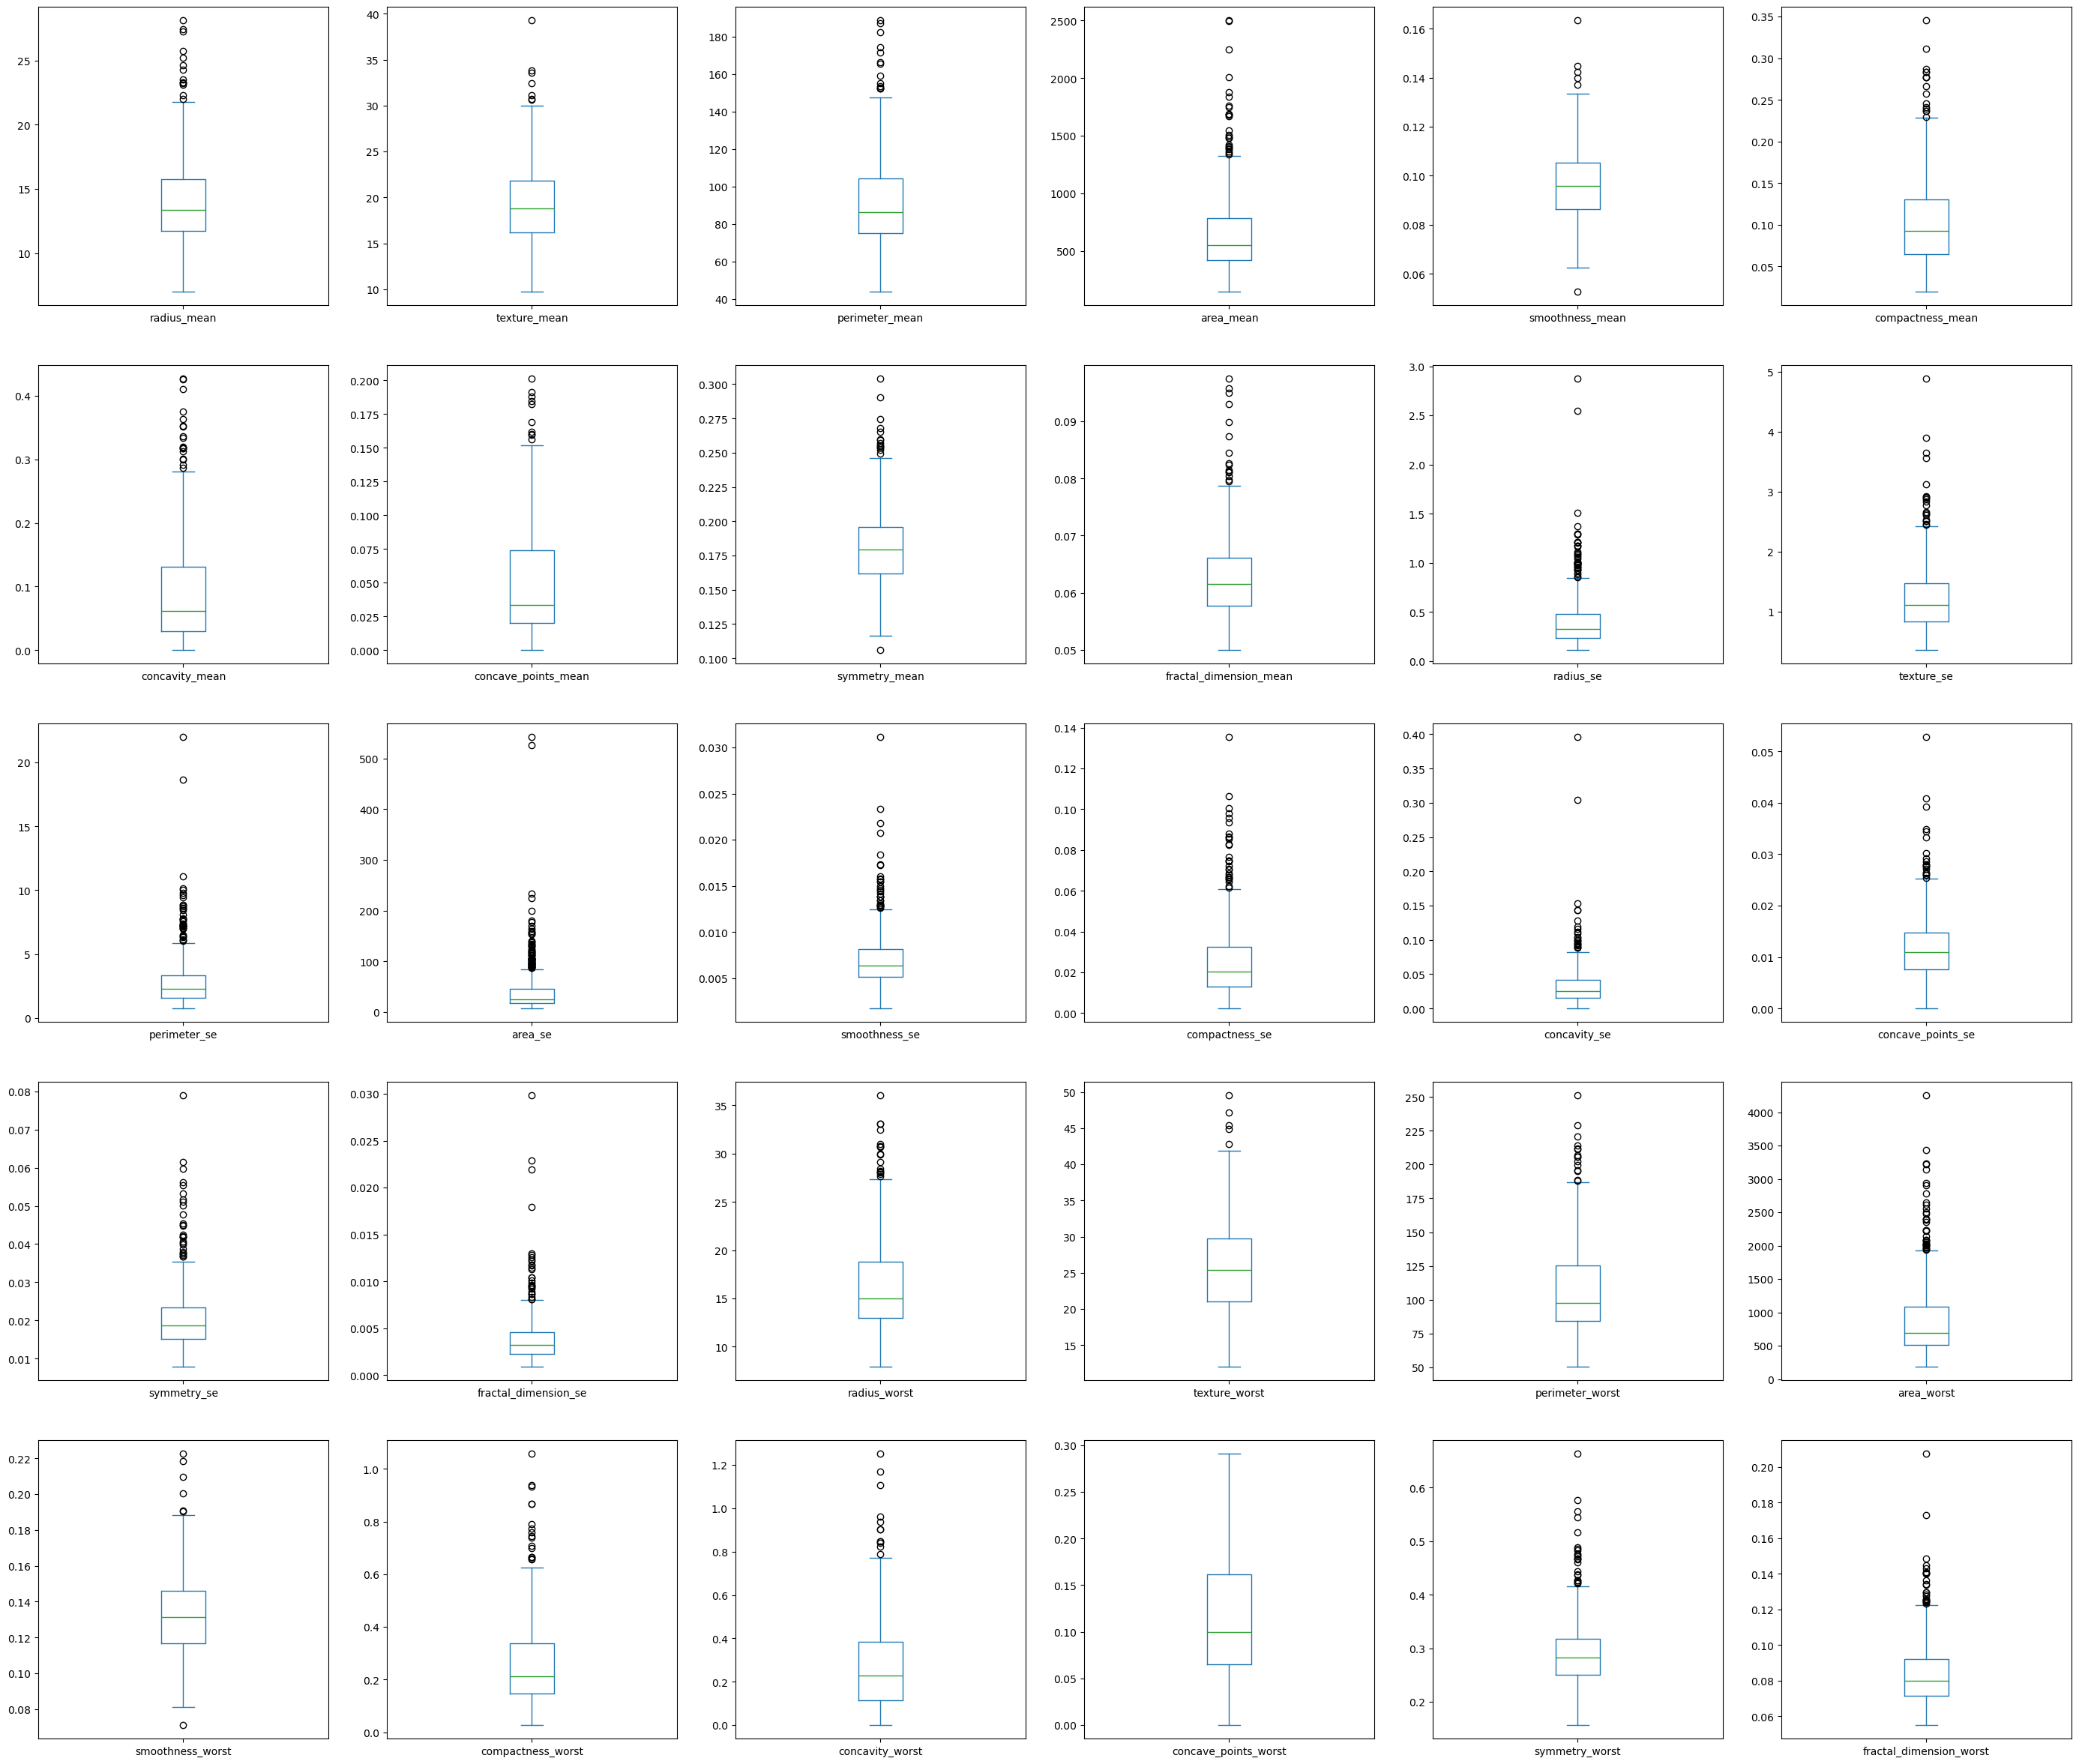

In [50]:
X.plot(kind='box', subplots=True, layout=(5, 6), figsize=(35, 30))
plt.show()

# EDA: Exploratory Data Analysis

### Variable Definitions and Medical Significance:

* **Radius**: The average distance from the centre to points on the cell nucleus perimeter. Cancerous cells typically exhibit larger nuclei than healthy ones.
* **Texture**: A measure of grey-scale variation within the pixels. It describes whether the cell nucleus surface appears smooth or coarse.
* **Perimeter**: The total length of the boundary surrounding the cell nucleus.
* **Area**: The total surface area of the cell nucleus. This is a vital indicator, as malignant cells often expand significantly.
* **Smoothness**: While benign cells are usually rounded and smooth, malignant cells often feature sharp edges or irregular protrusions.
* **Compactness**: Indicates how "neat" or condensed the cell shape is. Cancerous cells often appear elongated or structurally complex.
* **Concavity**: Measures the severity of indentations on the nuclear contour. Deep concavities are often a red flag for abnormal growth.
* **Concave Points**: A count of the indented portions of the boundary. A higher number of concave points suggests a more distorted nucleus.
* **Symmetry**: Measures whether the two halves of the nucleus match. Cancerous cells tend to grow unevenly, leading to a loss of symmetry.
* **Fractal Dimension**: A mathematical index describing boundary complexity. The more "rugged" or jagged the boundary, the higher this value.

---

### Data Variations


Each of the features above is recorded in three variations:

1.  **Mean**: The average value across all observed cells in the biopsy sample, providing a general overview of the tumour.
2.  **SE (Standard Error)**: Measures the variation between cells. For instance, a high `radius_se` suggests a non-uniform tumour containing both very large and small cells.
3.  **Worst**: Represents the "worst-case" or maximum value recorded for that feature. In a clinical context, this is often the most critical metric, as specialists focus on the most severely mutated cells to confirm a malignancy.


In [51]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.372583
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,0.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [52]:
df[df["diagnosis"] == 1].describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
count,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.0
mean,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990,0.192909,0.062680,0.609083,1.210915,4.323929,72.672406,0.006780,0.032281,0.041824,0.015060,0.020472,0.004062,21.134811,29.318208,141.370330,1422.286321,0.144845,0.374824,0.450606,0.182237,0.323468,0.091530,1.0
std,3.203971,3.779470,21.854653,367.937978,0.012608,0.053987,0.075019,0.034374,0.027638,0.007573,0.345039,0.483178,2.568546,61.355268,0.002890,0.018387,0.021603,0.005517,0.010065,0.002041,4.283569,5.434804,29.457055,597.967743,0.021870,0.170372,0.181507,0.046308,0.074685,0.021553,0.0
min,10.950000,10.380000,71.900000,361.600000,0.073710,0.046050,0.023980,0.020310,0.130800,0.049960,0.193800,0.362100,1.334000,13.990000,0.002667,0.008422,0.011010,0.005174,0.007882,0.001087,12.840000,16.670000,85.100000,508.100000,0.088220,0.051310,0.023980,0.028990,0.156500,0.055040,1.0
25%,15.075000,19.327500,98.745000,705.300000,0.094010,0.109600,0.109525,0.064620,0.174050,0.056598,0.390375,0.892825,2.715500,35.762500,0.005085,0.019662,0.026998,0.011415,0.014615,0.002688,17.730000,25.782500,119.325000,970.300000,0.130475,0.244475,0.326425,0.152750,0.276500,0.076302,1.0
50%,17.325000,21.460000,114.200000,932.000000,0.102200,0.132350,0.151350,0.086280,0.189900,0.061575,0.547200,1.102500,3.679500,58.455000,0.006209,0.028590,0.037125,0.014205,0.017700,0.003739,20.590000,28.945000,138.000000,1303.000000,0.143450,0.356350,0.404900,0.182000,0.310300,0.087600,1.0
75%,19.590000,23.765000,129.925000,1203.750000,0.110925,0.172400,0.203050,0.103175,0.209850,0.067075,0.757300,1.429250,5.206250,94.000000,0.007971,0.038910,0.050443,0.017497,0.022132,0.004892,23.807500,32.690000,159.800000,1712.750000,0.155975,0.447850,0.556175,0.210675,0.359225,0.102625,1.0
max,28.110000,39.280000,188.500000,2501.000000,0.144700,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,3.568000,21.980000,542.200000,0.031130,0.135400,0.143800,0.040900,0.078950,0.012840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.170000,0.291000,0.663800,0.207500,1.0


In [53]:
df[df["diagnosis"] == 0].describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
count,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.00000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.0
mean,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,0.174186,0.062867,0.284082,1.22038,2.000321,21.135148,0.007196,0.021438,0.025997,0.009858,0.020584,0.003636,13.379801,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442,0.0
std,1.780512,3.995125,11.807438,134.287118,0.013446,0.033750,0.043442,0.015909,0.024807,0.006747,0.112570,0.58918,0.771169,8.843472,0.003061,0.016352,0.032918,0.005709,0.006999,0.002938,1.981368,5.493955,13.527091,163.601424,0.020013,0.092180,0.140368,0.035797,0.041745,0.013804,0.0
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.051850,0.111500,0.36020,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.009539,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156600,0.055210,0.0
25%,11.080000,15.150000,70.870000,378.200000,0.083060,0.055620,0.020310,0.015020,0.158000,0.058530,0.207300,0.79590,1.445000,15.260000,0.005212,0.011320,0.010990,0.006433,0.015600,0.002074,12.080000,19.580000,78.270000,447.100000,0.110400,0.112000,0.077080,0.051040,0.240600,0.070090,0.0
50%,12.200000,17.390000,78.180000,458.400000,0.090760,0.075290,0.037090,0.023440,0.171400,0.061540,0.257500,1.10800,1.851000,19.630000,0.006530,0.016310,0.018400,0.009061,0.019090,0.002808,13.350000,22.820000,86.920000,547.400000,0.125400,0.169800,0.141200,0.074310,0.268700,0.077120,0.0
75%,13.370000,19.760000,86.100000,551.100000,0.100700,0.097550,0.059990,0.032510,0.189000,0.065760,0.341600,1.49200,2.388000,25.030000,0.008534,0.025890,0.030560,0.011870,0.024060,0.004174,14.800000,26.510000,96.590000,670.000000,0.137600,0.230200,0.221600,0.097490,0.298300,0.085410,0.0
max,17.850000,33.810000,114.600000,992.100000,0.163400,0.223900,0.410800,0.085340,0.274300,0.095750,0.881100,4.88500,5.118000,77.110000,0.021770,0.106400,0.396000,0.052790,0.061460,0.029840,19.820000,41.780000,127.100000,1210.000000,0.200600,0.584900,1.252000,0.175000,0.422800,0.148600,0.0


## Question 1: Do malignant (M) tumours always have larger feature values than benign (B) tumours?

Motivation
A common assumption in cancer diagnosis is that malignant cells are larger and more irregular 
than benign ones. This question tests whether that assumption holds universally across all 30 
features in the dataset, or whether some features behave unexpectedly.

Approach
For each feature, we identified:
- The maximum value across all samples and checked whether it belonged to a malignant (1) 
  or benign (0) case
- The minimum value across all samples and checked whether it belonged to a malignant (1) 
  or benign (0) case

If malignant tumours are always larger/more extreme, we would expect:
- All maximum values → Diagnosis: 1 (Malignant)
- All minimum values → Diagnosis: 0 (Benign)

In [54]:
for column in X.columns:
    max_value = X[column].max()
    max_index = X[column].idxmax() # return row have the max value
    corresponding_diagnosis = df.loc[max_index, 'diagnosis']
    print(f"{column} have the max value = {max_value:4f}, Diagnosis: {corresponding_diagnosis}")

radius_mean have the max value = 28.110000, Diagnosis: 1
texture_mean have the max value = 39.280000, Diagnosis: 1
perimeter_mean have the max value = 188.500000, Diagnosis: 1
area_mean have the max value = 2501.000000, Diagnosis: 1
smoothness_mean have the max value = 0.163400, Diagnosis: 0
compactness_mean have the max value = 0.345400, Diagnosis: 1
concavity_mean have the max value = 0.426800, Diagnosis: 1
concave_points_mean have the max value = 0.201200, Diagnosis: 1
symmetry_mean have the max value = 0.304000, Diagnosis: 1
fractal_dimension_mean have the max value = 0.097440, Diagnosis: 1
radius_se have the max value = 2.873000, Diagnosis: 1
texture_se have the max value = 4.885000, Diagnosis: 0
perimeter_se have the max value = 21.980000, Diagnosis: 1
area_se have the max value = 542.200000, Diagnosis: 1
smoothness_se have the max value = 0.031130, Diagnosis: 1
compactness_se have the max value = 0.135400, Diagnosis: 1
concavity_se have the max value = 0.396000, Diagnosis: 0
con

In [55]:
for column in X.columns:
    min_value = X[column].min()
    min_index = X[column].idxmin() # return row have the min value
    corresponding_diagnosis = df.loc[min_index, 'diagnosis']
    print(f"{column} have the min value = {min_value:4f}, Diagnosis: {corresponding_diagnosis}")

radius_mean have the min value = 6.981000, Diagnosis: 0
texture_mean have the min value = 9.710000, Diagnosis: 0
perimeter_mean have the min value = 43.790000, Diagnosis: 0
area_mean have the min value = 143.500000, Diagnosis: 0
smoothness_mean have the min value = 0.052630, Diagnosis: 0
compactness_mean have the min value = 0.019380, Diagnosis: 0
concavity_mean have the min value = 0.000000, Diagnosis: 0
concave_points_mean have the min value = 0.000000, Diagnosis: 0
symmetry_mean have the min value = 0.106000, Diagnosis: 0
fractal_dimension_mean have the min value = 0.049960, Diagnosis: 1
radius_se have the min value = 0.111500, Diagnosis: 0
texture_se have the min value = 0.360200, Diagnosis: 0
perimeter_se have the min value = 0.757000, Diagnosis: 0
area_se have the min value = 6.802000, Diagnosis: 0
smoothness_se have the min value = 0.001713, Diagnosis: 0
compactness_se have the min value = 0.002252, Diagnosis: 0
concavity_se have the min value = 0.000000, Diagnosis: 0
concave_po

__Key Findings for Question 1__

Maximum values — features where the global maximum belongs to a Benign case (unexpected):
- smoothness_mean: max = 0.1634, Diagnosis: 0 (Benign)
- texture_se: max = 4.885, Diagnosis: 0 (Benign)
- concavity_se: max = 0.396, Diagnosis: 0 (Benign)
- concave_points_se: max = 0.05279, Diagnosis: 0 (Benign)
- fractal_dimension_se: max = 0.02984, Diagnosis: 0 (Benign)
- concavity_worst: max = 1.252, Diagnosis: 0 (Benign)

For all other features (radius, perimeter, area, texture_mean, compactness, etc.),
the global maximum belongs to a malignant case, which aligns with the assumption.

Minimum values — features where the global minimum belongs to a Malignant case (unexpected):
- fractal_dimension_mean: min = 0.04996, Diagnosis: 1 (Malignant)
- symmetry_se: min = 0.007882, Diagnosis: 1 (Malignant)
- symmetry_worst: min = 0.1565, Diagnosis: 1 (Malignant)
- fractal_dimension_worst: min = 0.05504, Diagnosis: 1 (Malignant)

For all other features, the global minimum belongs to a benign case.

Answer:
No, malignant tumours do not always have larger values than benign ones.
The assumption holds strongly for size-related features (radius, perimeter, area)
and shape irregularity features (concave_points, compactness), where malignant cases
dominate the extremes.

However, 6 features have their global maximum in a benign case, and 4 features
have their global minimum in a malignant case. These exceptions are concentrated in:
- SE (standard error) features: high SE in a benign case simply means that particular
  biopsy had highly variable cells, which does not necessarily indicate cancer.
- Fractal dimension and symmetry: these shape complexity measures do not follow
  a simple "malignant = more extreme" rule, as both very regular and very irregular
  shapes can appear in either class.

Takeaway
Size and concavity features are reliable one-directional indicators of malignancy.
However, variability (SE) and shape complexity (fractal dimension, symmetry) features
are more nuanced — their extreme values can appear in either class, making them
weaker standalone predictors but still useful in combination with other features.

## Question 2: Is the dataset balanced or imbalanced, and how are Benign (B) and Malignant (M) cases distributed across each feature? How does class imbalance affect model performance?

Motivation
Understanding the class distribution is a critical first step before any modelling. If one
class dominates the dataset, a naive model could achieve high accuracy simply by predicting
the majority class every time. It is also important to understand how B and M cases are
distributed across each feature, as this reveals which features are most useful for
distinguishing between the two classes.

Approach
Two visualisations were used to answer this question:

1. A pie chart of the target variable (diagnosis) to assess overall class balance.
2. Overlapping histograms for each of the 30 features, showing the distribution of
   Benign (skyblue) and Malignant (salmon) cases side by side.

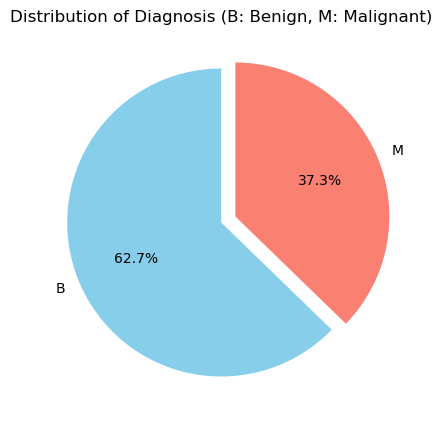

In [56]:
plt.figure(figsize=(5, 5))
plt.pie(y.value_counts(), explode= [0,0.1], labels= ["B", "M" ], colors= ['skyblue','salmon'], autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Diagnosis (B: Benign, M: Malignant)')
plt.show()

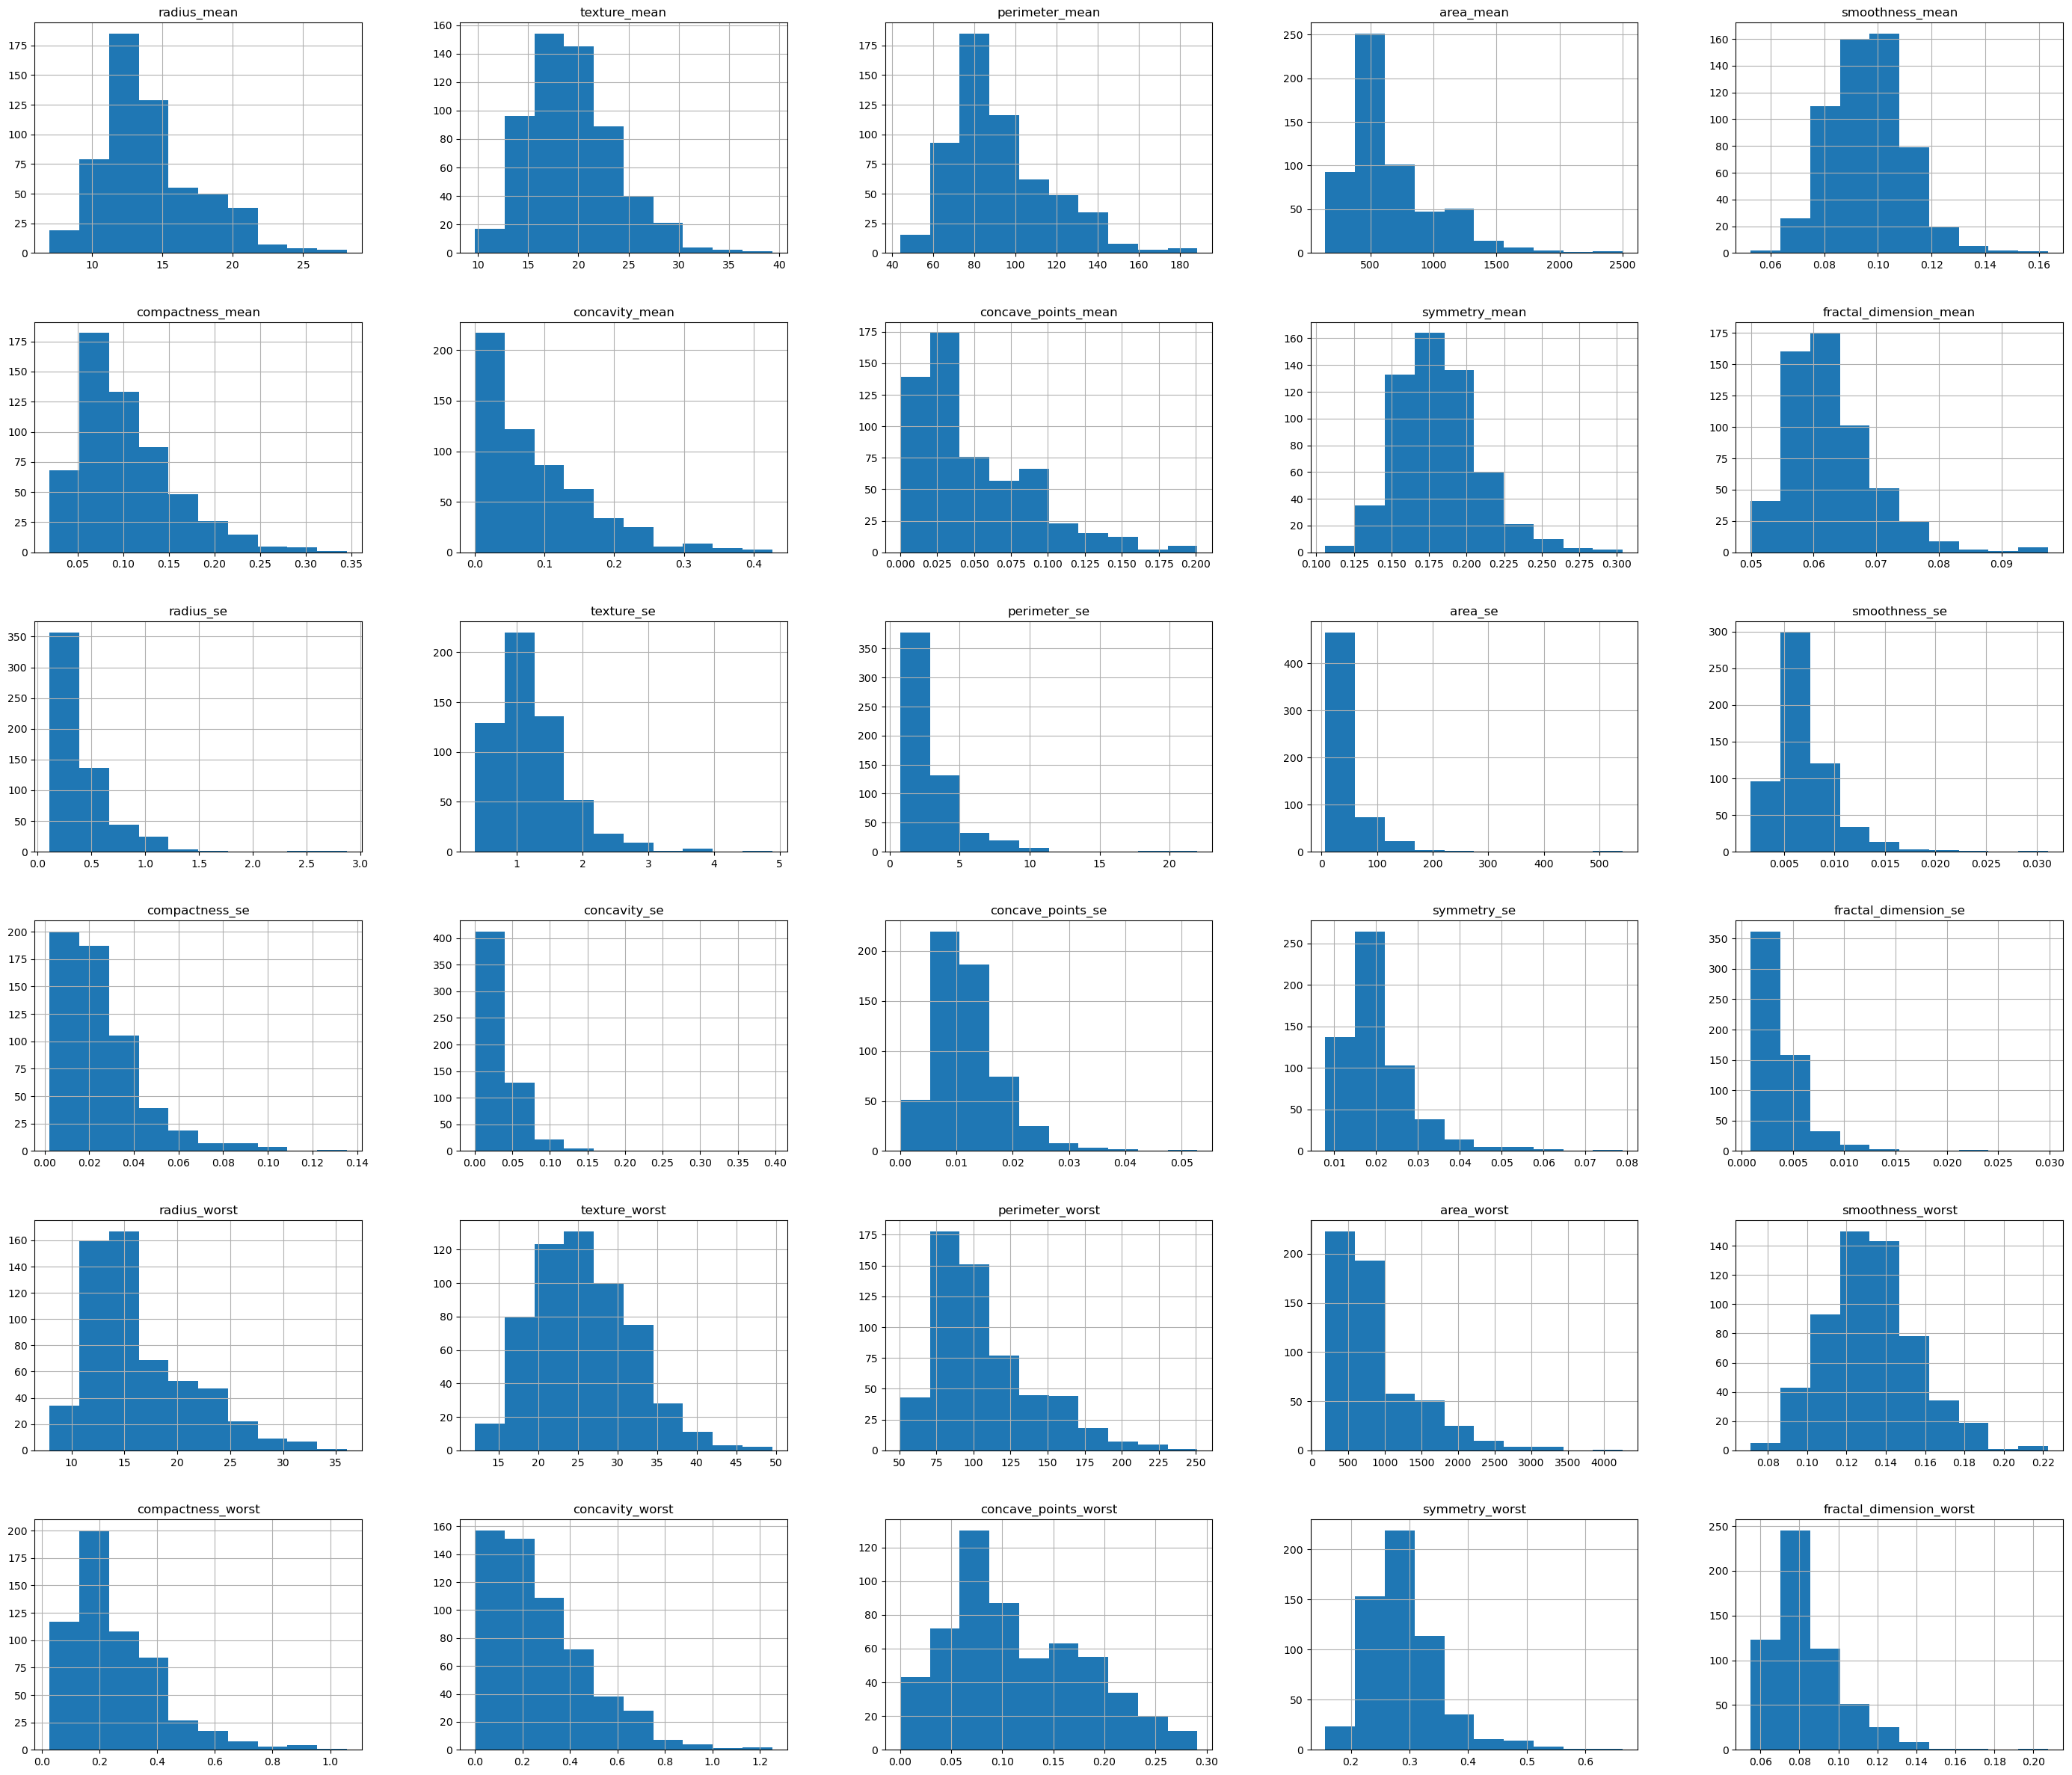

In [57]:
X.hist(figsize = (35,30))
plt.show()

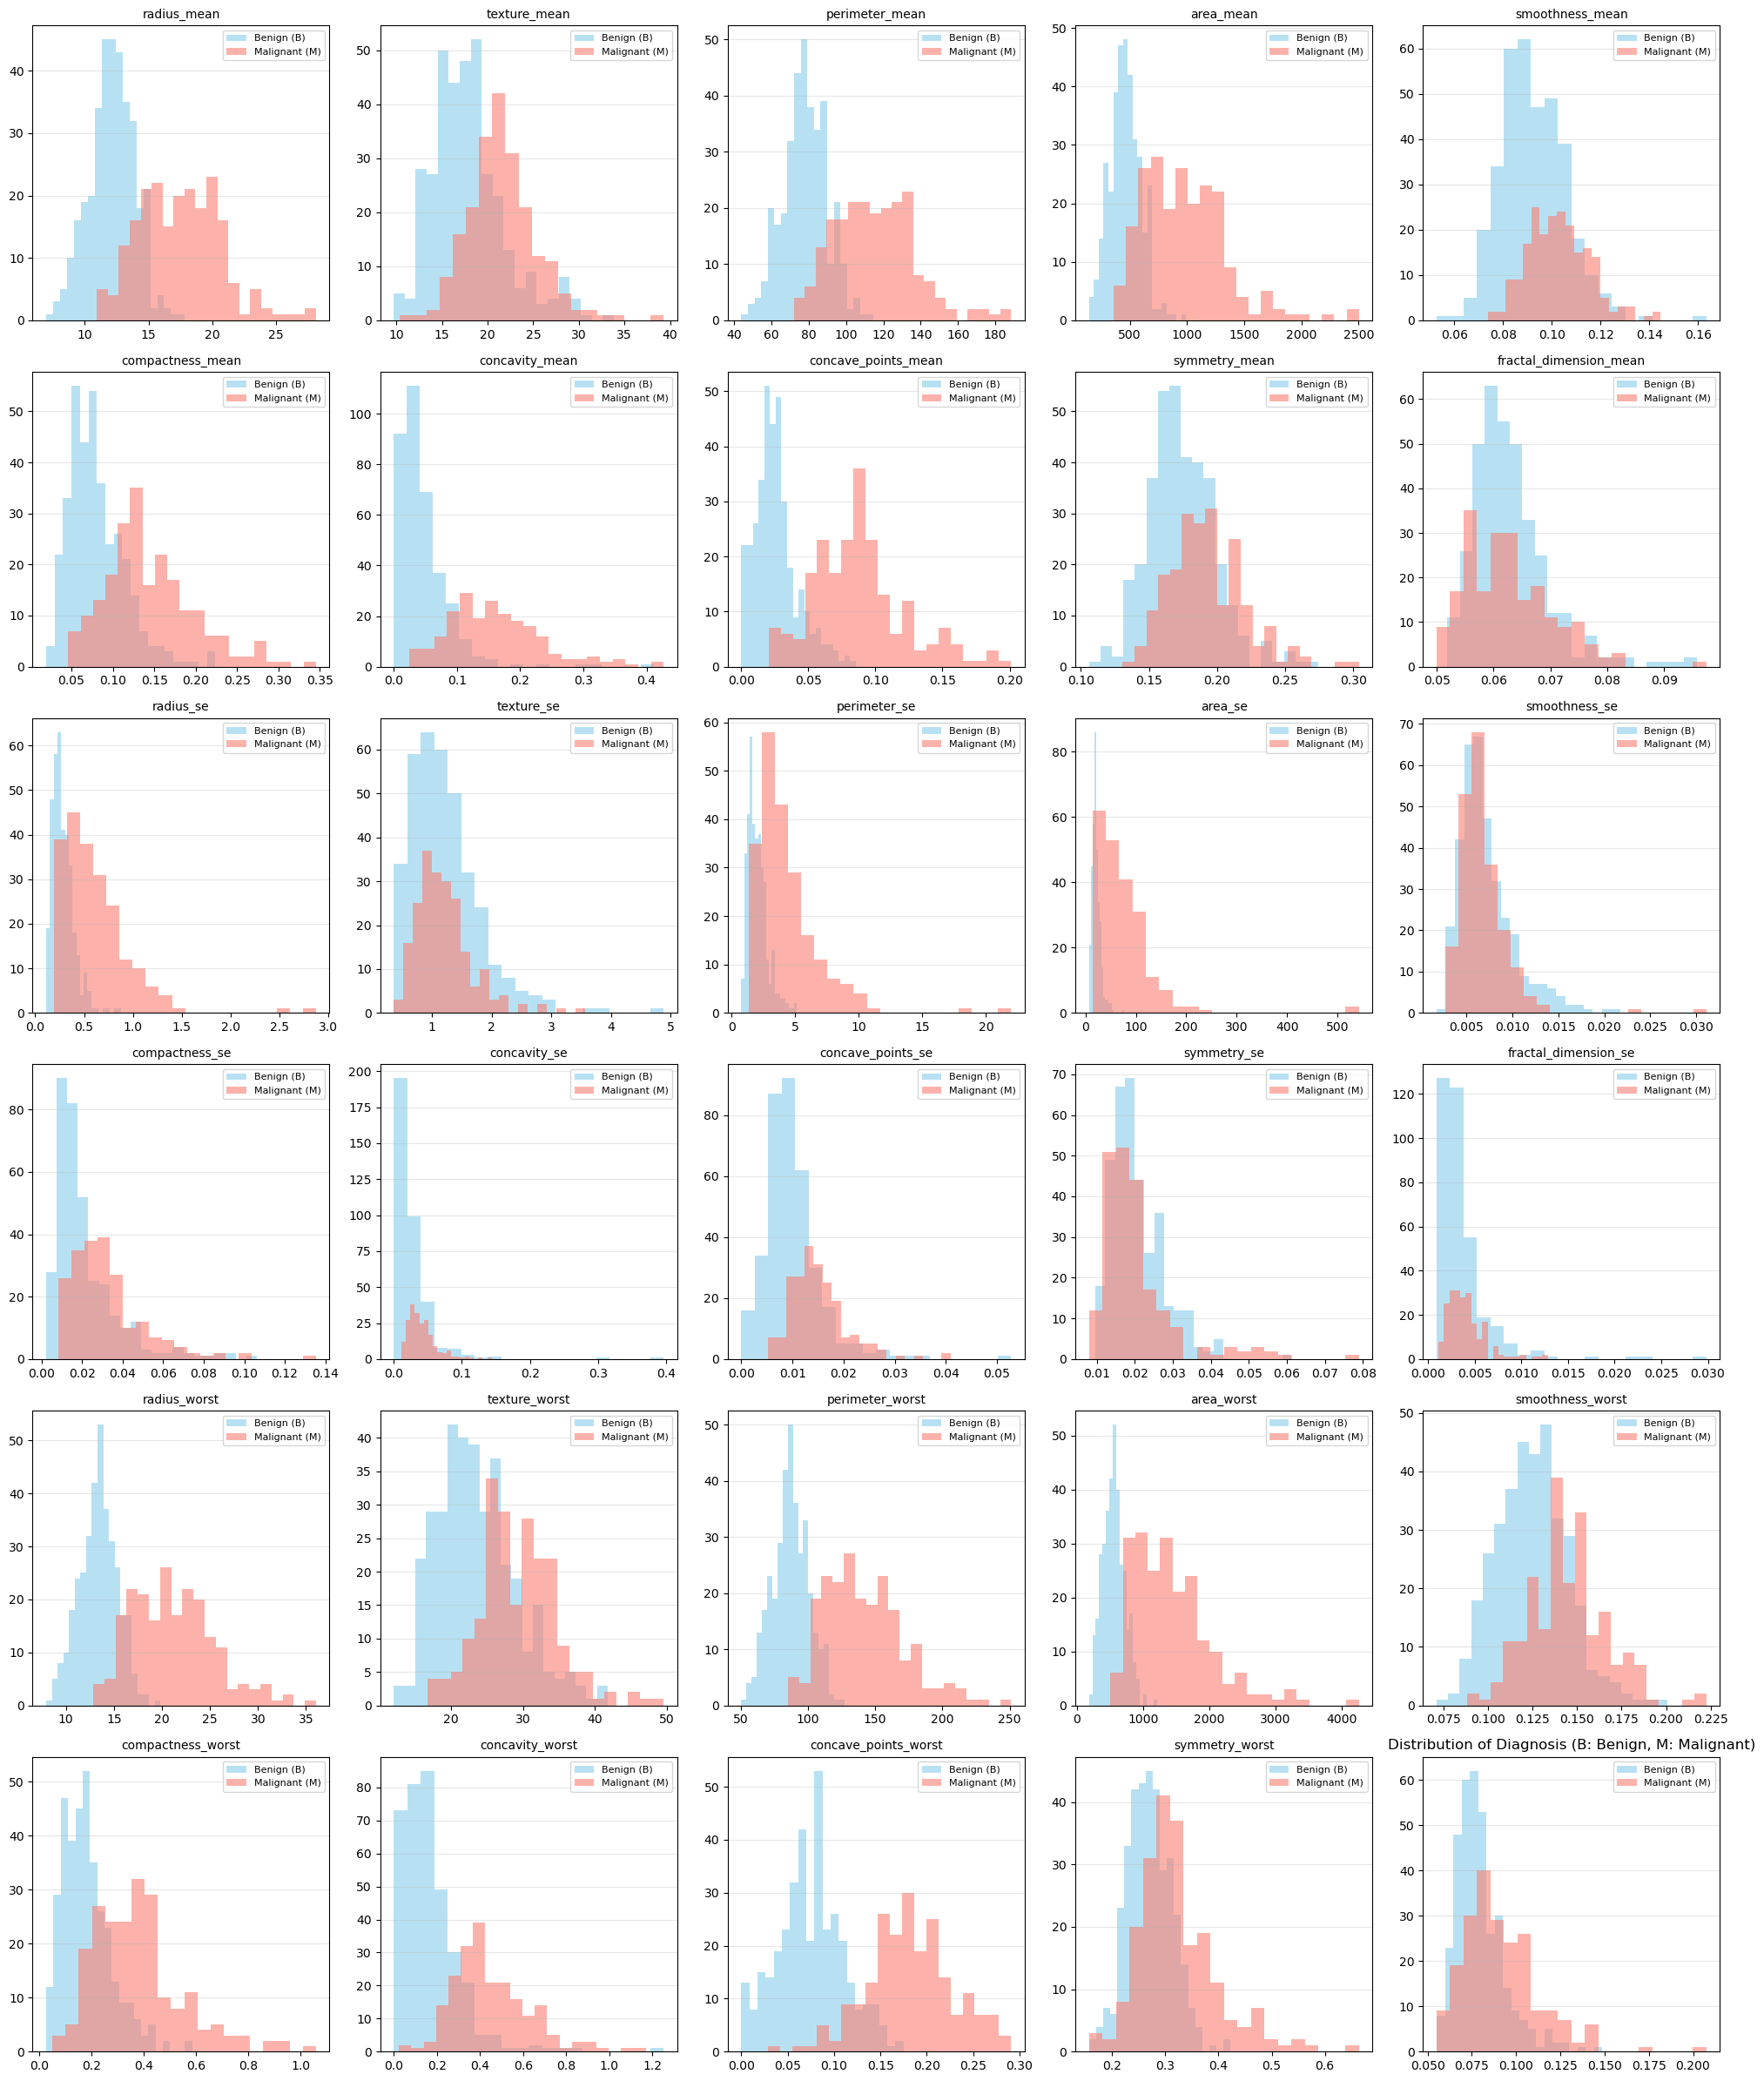

In [58]:
cols_per_row = 5
num_columns = len(X.columns)

fig, axes = plt.subplots(6, cols_per_row, figsize=(20, 4 * 6))
axes = axes.flatten()

for i, column in enumerate(X.columns):

    axes[i].hist(X[y == 0][column], bins=20, alpha=0.6, label='Benign (B)', color='skyblue')
    axes[i].hist(X[y == 1][column], bins=20, alpha=0.6, label='Malignant (M)', color='salmon')

    axes[i].set_title(f'{column}', fontsize=10)
    axes[i].legend(fontsize=8)
    axes[i].grid(axis='y', alpha=0.3)

plt.title('Distribution of Diagnosis (B: Benign, M: Malignant)')
plt.tight_layout()
plt.show()

__Key Findings for Question 2__

Class Distribution (Pie Chart):
The dataset contains 357 Benign cases (62.7%) and 212 Malignant cases (37.3%).
This confirms a moderate class imbalance — Benign cases outnumber Malignant by roughly 1.7:1.
While not extreme, this imbalance is meaningful in a medical context where failing to detect
a malignant case (false negative) carries serious consequences.

Feature Distributions (Overlapping Histograms):
The histograms reveal three patterns across features:

1. Well-separated features (most useful for classification):
   Size-related features such as radius_mean, perimeter_mean, area_mean, radius_worst,
   perimeter_worst, and area_worst show clear separation between B and M distributions.
   Malignant cases (salmon) are visibly shifted to the right, clustering at higher values
   with minimal overlap. concave_points_mean and concave_points_worst also show strong
   separation, with Malignant cases dominating higher values. These are the most
   discriminating features in the dataset.

2. Partially overlapping features (moderately useful):
   Features like compactness_mean, concavity_mean, compactness_worst, and concavity_worst
   show some separation but with notable overlap between B and M distributions.
   Notably, texture_mean appears more overlapping than expected — the two distributions
   are quite mixed despite texture being a commonly cited diagnostic indicator.
   These features provide supporting signal but are not reliable on their own.

3. Heavily overlapping features (least useful standalone):
   SE features as a whole group show the least separation — across almost all SE features
   (smoothness_se, texture_se, concavity_se, concave_points_se, fractal_dimension_se),
   the Benign and Malignant distributions are nearly identical, providing minimal
   discriminating power on their own. Similarly, smoothness_mean, symmetry_se,
   and fractal_dimension_mean show near-identical distributions for both classes.
   This visually confirms why SE features are the weakest predictors and is consistent
   with the finding in Question 1 where SE features had unexpected extreme values
   in benign cases.

Effect of Class Imbalance on Modelling:
The 62.7% vs 37.3% imbalance was addressed in two ways in this project:

1. class_weight="balanced" was applied in Logistic Regression, which automatically adjusts
   the penalty for misclassifying the minority class (Malignant), making the model more
   sensitive to detecting cancer cases.

2. F1 score was used as the primary evaluation metric instead of accuracy. A model that
   predicts Benign every time would achieve 62.7% accuracy but an F1 score near 0 for the
   Malignant class, exposing the true weakness of such a model.

These choices proved effective — Logistic Regression achieved only 1 false negative across
171 test samples, demonstrating that the imbalance was well handled.

Answer
The dataset is moderately imbalanced (62.7% Benign vs 37.3% Malignant). Size-related and
concavity features show the clearest separation between classes and are the most useful for
classification. SE features and fractal dimension features show the heaviest overlap between
classes and contribute the least individually. The imbalance was mitigated through balanced
class weighting and F1-based evaluation, resulting in strong model performance with minimal
missed cancer cases.

Takeaway
Class imbalance, if unaddressed, can cause a model to be biased toward the majority class
and miss malignant cases. Using class_weight="balanced" and optimising for F1 score rather
than accuracy ensures the model prioritises correctly identifying cancer — which is the
most critical outcome in a medical classification task.

## Question 3: Do all features equally affect the model, and is there multicollinearity present in the dataset?

Motivation
Not all features contribute equally to a predictive model. Including redundant or irrelevant
features can introduce noise, increase model complexity, and in the case of Logistic
Regression, multicollinearity — where two or more features are highly correlated with each
other — can destabilise coefficient estimates and make the model harder to interpret.
Identifying which features truly drive predictions and which are redundant is important for
building a reliable and interpretable model.

Approach
The correlation heatmap was used to investigate two things:
1. Which features are most correlated with the target variable (diagnosis), indicating
   their individual predictive importance.
2. Which features are highly correlated with each other, indicating potential
   multicollinearity problems.

A correlation value above 0.70 between two features is considered a strong correlation,
and above 0.90 is considered a near-perfect/redundant relationship.

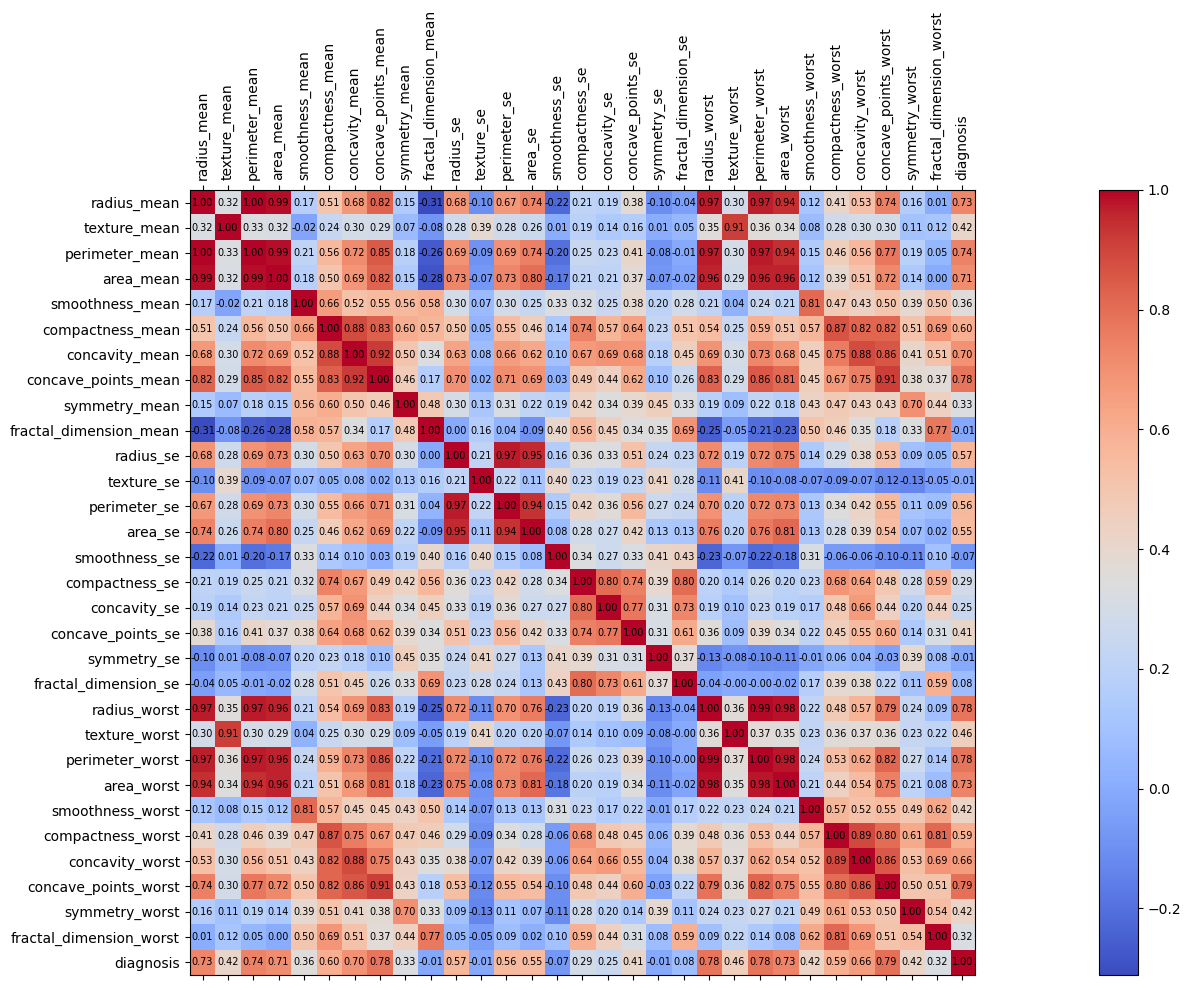

In [59]:
# Correlation heat map
corr = df.corr()
fig, ax = plt.subplots(figsize=(25, 10))
cax = ax.matshow(corr, cmap="coolwarm")
fig.colorbar(cax)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)

plt.tight_layout()
plt.show()

__Key Findings for Question 3__

Feature Correlation with Diagnosis (last row/column of heatmap):
Strong positive correlation with diagnosis (above 0.70):
- concave_points_worst: 0.79
- perimeter_worst: 0.78
- concave_points_mean: 0.78
- radius_worst: 0.78
- area_worst: 0.73
- perimeter_mean: 0.74
- radius_mean: 0.73

Weak correlation with diagnosis (below 0.30):
- fractal_dimension_mean: 0.01
- texture_se: 0.01
- smoothness_se: 0.07
- symmetry_se: 0.01
- fractal_dimension_se: 0.08

This confirms that size and concavity features are the primary drivers of the model,
while most SE features contribute almost no individual predictive signal.

Multicollinearity Findings:
The heatmap reveals severe multicollinearity across several feature groups:

1. Size feature group — near-perfect correlations:
   - radius_mean, perimeter_mean, area_mean are correlated at ~0.99 with each other
   - radius_worst, perimeter_worst, area_worst are similarly correlated at ~0.99
   - radius_mean and radius_worst correlate at ~0.97
   These features are essentially measuring the same thing (tumour size) in different ways,
   making them largely redundant when used together.

2. Concavity feature group — strong correlations:
   - concave_points_mean and concavity_mean correlate at ~0.82
   - concave_points_worst and concavity_worst correlate at ~0.86
   - Mean and worst versions of the same feature also correlate strongly (~0.75-0.90)

3. Mean and Worst versions:
   Almost every feature's _mean and _worst version are highly correlated (above 0.80),
   meaning including both adds limited new information.

Why This Matters for the Model:
Multicollinearity does not affect predictive accuracy significantly, but it does affect
coefficient interpretation in Logistic Regression. When two features are near-perfectly
correlated (e.g. radius_mean and perimeter_mean at 0.99), the model cannot reliably
distinguish their individual contributions — it may assign a large positive coefficient
to one and a near-zero or even negative coefficient to the other arbitrarily.

This explains a key observation from the feature importance chart in Question 1:
radius_mean had a near-zero coefficient despite being clinically significant, because
its predictive signal was already captured by perimeter_mean and area_mean.

How This Was Addressed:
L1 (Lasso) and L2 (Ridge) regularisation were both included in the hyperparameter search
via the penalty parameter. L1 regularisation in particular handles multicollinearity by
driving redundant feature coefficients toward zero, effectively performing automatic
feature selection. The final model selected via cross-validation used one of these
penalties, helping to stabilise coefficients in the presence of multicollinearity.

Answer
No, not all features contribute equally to the model. Size-related features
(radius, perimeter, area) and concavity features are the strongest predictors, while
most SE features and fractal dimension features have near-zero correlation with diagnosis
and contribute minimal predictive value individually. Significant multicollinearity exists
particularly among size features (correlations up to 0.99) and between mean/worst versions
of the same feature. This was addressed through L1/L2 regularisation in Logistic Regression,
which penalises redundant coefficients and produces a more stable, interpretable model.

Takeaway
Multicollinearity is an important issue to address in Logistic Regression because it makes
individual coefficients unreliable and hard to interpret. Identifying highly correlated
feature groups also provides insight into the underlying biology such as radius, perimeter, and
area all measure tumour size, so their redundancy is expected. Regularisation ensures the
model remains robust despite these correlations.

# Data Preparation and Feature Engineering


In [60]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, shuffle = True, stratify=y)


In [61]:
def handle_outliers_train_test(X_train, X_test):

    X_train_clean = X_train.copy()
    X_test_clean = X_test.copy()
    outlier_bounds = {}

    for column in X_train.columns:
        Q1 = X_train[column].quantile(0.25)
        Q3 = X_train[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outlier_bounds[column] = {'lower': float(lower_bound),'upper': float(upper_bound)}

        outliers_train = ((X_train[column] < lower_bound) |
                         (X_train[column] > upper_bound)).sum()
        outliers_test = ((X_test[column] < lower_bound) |
                        (X_test[column] > upper_bound)).sum()

        X_train_clean[column] = X_train[column].clip(lower_bound, upper_bound)
        X_test_clean[column] = X_test[column].clip(lower_bound, upper_bound)

        if outliers_train > 0 or outliers_test > 0:
            print(f"{column}: Train outliers={outliers_train}, "
                  f"Test outliers={outliers_test}")


    return X_train_clean, X_test_clean, outlier_bounds

X_train, X_test, outlier_bounds = handle_outliers_train_test(X_train, X_test)

radius_mean: Train outliers=11, Test outliers=1
texture_mean: Train outliers=5, Test outliers=2
perimeter_mean: Train outliers=12, Test outliers=1
area_mean: Train outliers=20, Test outliers=3
smoothness_mean: Train outliers=5, Test outliers=1
compactness_mean: Train outliers=14, Test outliers=1
concavity_mean: Train outliers=17, Test outliers=1
concave_points_mean: Train outliers=9, Test outliers=1
symmetry_mean: Train outliers=13, Test outliers=3
fractal_dimension_mean: Train outliers=12, Test outliers=3
radius_se: Train outliers=31, Test outliers=5
texture_se: Train outliers=15, Test outliers=5
perimeter_se: Train outliers=34, Test outliers=4
area_se: Train outliers=53, Test outliers=11
smoothness_se: Train outliers=20, Test outliers=10
compactness_se: Train outliers=24, Test outliers=5
concavity_se: Train outliers=24, Test outliers=5
concave_points_se: Train outliers=17, Test outliers=3
symmetry_se: Train outliers=22, Test outliers=7
fractal_dimension_se: Train outliers=23, Test ou

In [62]:
# Scale
scaler = StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Training



### Logistic Regression

In [63]:
def validate_model_kfold(model, param_dist, X_train, y_train, n_splits=5, n_iter=20):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    # Random Search
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=n_iter,
        cv=skf,
        scoring='f1',
        n_jobs=-1,
        verbose=1,
        random_state=42)

    search.fit(X_train, y_train)

    best_index = search.best_index_
    fold_scores = []
    for fold in range(n_splits):
        fold_score = search.cv_results_[f'split{fold}_test_score'][best_index]
        fold_scores.append(fold_score)

    # Bar chart
    mean_f1 = np.mean(fold_scores)
    folds = [f'Fold {i+1}' for i in range(n_splits)]

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(folds, fold_scores, color='steelblue', edgecolor='white', width=0.5)
    ax.axhline(mean_f1, color='tomato', linestyle='--', linewidth=1.5, label=f'Mean F1: {mean_f1:.2%}')

    for bar, score in zip(bars, fold_scores):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{score:.2%}', ha='center', va='bottom', fontsize=10)

    ax.set_title('F1 Score per Fold')
    ax.set_xlabel('Fold')
    ax.set_ylabel('F1 Score')
    ax.set_ylim(0, 1.1)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    print(f"Best hyperparameters: {search.best_params_}")
    print(f"CV F1 score: {search.best_score_:.2%}")

    return search.best_estimator_, search.best_params_

Fitting 5 folds for each of 6 candidates, totalling 30 fits


/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=20. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


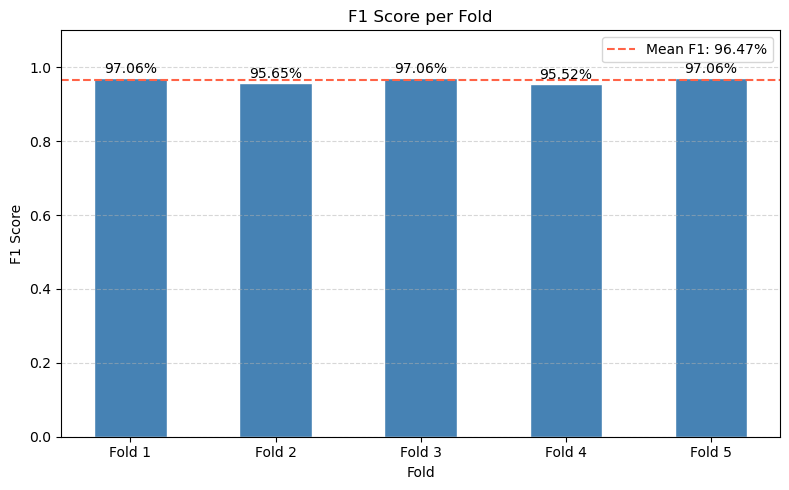

Best hyperparameters: {'solver': 'liblinear', 'penalty': 'l2', 'class_weight': 'balanced', 'C': 0.1}
CV F1 score: 96.47%


In [ ]:
param_dist_lr = {
    'penalty': ['l1','l2'],
    'solver': ['liblinear'],
    'C': [0.001,0.01,0.1],
    'class_weight':["balanced"]
}
 
logistic_regression_model, best_lr_params= validate_model_kfold(
    LogisticRegression(random_state = 42, max_iter= 1000),
    param_dist_lr,
    X_train_scaled,
    y_train)


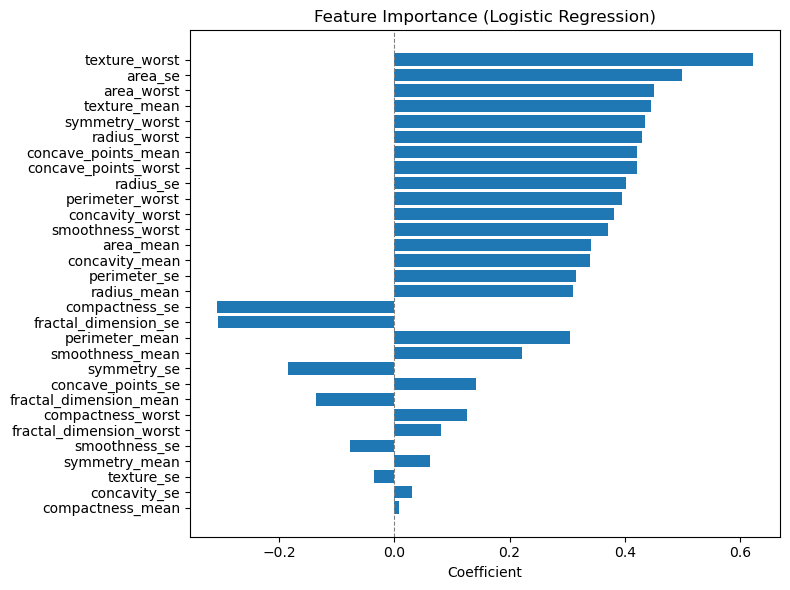

In [65]:
feature_names = np.array(X.columns)
coefs = logistic_regression_model.coef_[0]
sorted_idx = np.argsort(np.abs(coefs))

plt.figure(figsize=(8, 6))
plt.barh(feature_names[sorted_idx], coefs[sorted_idx])
plt.axvline(0, color='gray', linewidth=0.8, linestyle='--')
plt.title('Feature Importance (Logistic Regression)')
plt.xlabel('Coefficient')
plt.tight_layout()
plt.show()

Test F1 score: 98.80%

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99        72
           1       1.00      0.98      0.99        42

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



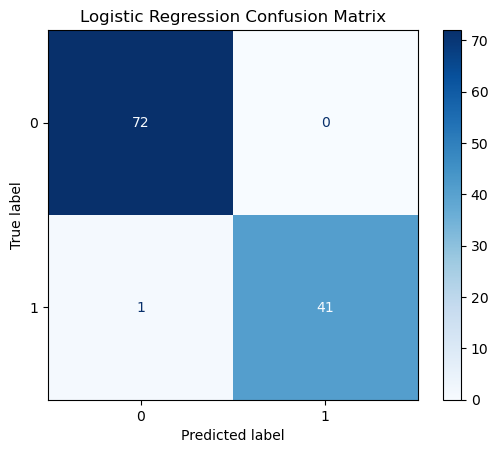

In [66]:
# Test model
y_pred = logistic_regression_model.predict(X_test_scaled)
test_f1 = f1_score(y_test, y_pred)
print(f"Test F1 score: {test_f1 * 100:.2f}%\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

#Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

### MLP

Fitting 5 folds for each of 20 candidates, totalling 100 fits


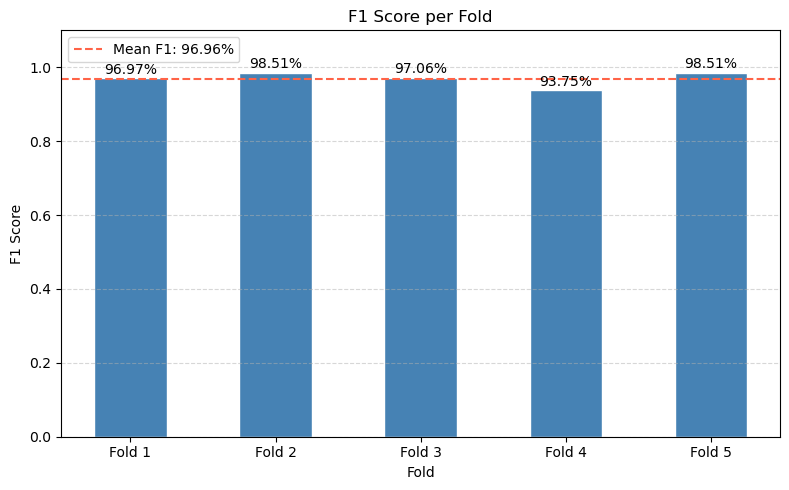

Best hyperparameters: {'solver': 'adam', 'learning_rate_init': 0.01, 'hidden_layer_sizes': (128, 64, 32), 'early_stopping': True, 'batch_size': 32, 'alpha': 0.1, 'activation': 'relu'}
CV F1 score: 96.96%


In [67]:
param_dist_mlp = {
    'hidden_layer_sizes': [
        (128,),
        (64, 32),
        (128, 64, 32),
        (128, 64, 32, 16),
        (256,128,64,64,32,16)],
    'activation': ['relu'],
    'solver': ['adam'],
    'alpha': [0.0001, 0.001, 0.01, 0.1],
    'learning_rate_init': [0.001, 0.01, 0.1],
    'batch_size': [32, 64, 128],
    'early_stopping': [True]
}

mlp_model,best_mlp_params = validate_model_kfold(
    MLPClassifier(random_state=42, max_iter=1000),
    param_dist_mlp,
    X_train_scaled, y_train
)

Early stopping at epoch 13


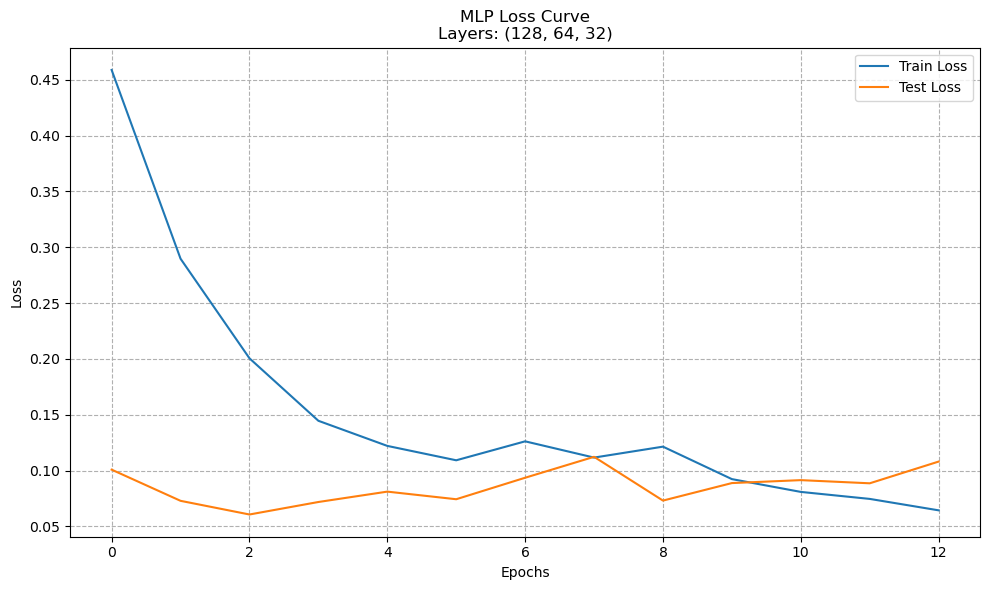

In [68]:
plot_params = best_mlp_params.copy()
plot_params['early_stopping'] = False

best_mlp_for_plot = MLPClassifier(
    **plot_params,
    warm_start=True,
    max_iter=1,
    random_state=42
)

train_losses = []
test_losses = []
epochs = 200
classes = np.unique(y_train)

best_test_loss = float('inf')
patience = 10
patience_counter = 0

for epoch in range(epochs):
    best_mlp_for_plot.partial_fit(X_train_scaled, y_train, classes=classes)

    train_losses.append(best_mlp_for_plot.loss_)

    test_probs = best_mlp_for_plot.predict_proba(X_test_scaled)
    test_loss = log_loss(y_test, test_probs)
    test_losses.append(test_loss)

    if test_loss < best_test_loss:
        best_test_loss = test_loss
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch + 1}")
        break

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title(f"MLP Loss Curve\nLayers: {best_mlp_params.get('hidden_layer_sizes')}")
plt.xlabel("Epochs",)
plt.ylabel("Loss")
plt.grid(True, linestyle='--')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

Test F1 score: 94.12%

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.96      0.97        72
           1       0.93      0.95      0.94        42

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



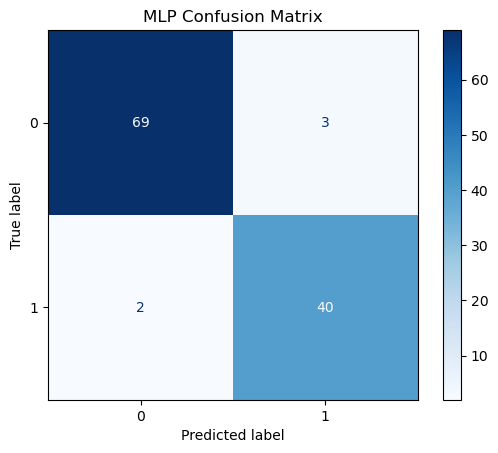

In [69]:
# Test model
y_pred = mlp_model.predict(X_test_scaled)
test_f1 = f1_score(y_test, y_pred)
print(f"Test F1 score: {test_f1 * 100:.2f}%\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

#Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title("MLP Confusion Matrix")
plt.show()